In [3]:
# Download DPP-4 bioactivity data (ChEMBL) into a CSV

import pandas as pd
from chembl_webresource_client.new_client import new_client

# Target search: DPP4
target = new_client.target
targets = target.search("DPP4")

# Show top matches
pd.DataFrame(targets).head(5)[["target_chembl_id", "pref_name", "organism"]]


,target_chembl_id,pref_name,organism
0,CHEMBL3813,Dipeptidyl peptidase 4,Sus scrofa
1,CHEMBL2559,Dipeptidyl peptidase 4,Bos taurus
2,CHEMBL284,Dipeptidyl peptidase 4,Homo sapiens
3,CHEMBL3883,Dipeptidyl peptidase 4,Mus musculus
4,CHEMBL2111469,Dipeptidyl peptidase II and dipeptidyl peptida...,Homo sapiens


In [4]:
# Pick the correct DPP-4 target ID (Homo sapiens)
t = pd.DataFrame(targets)

# Filter likely DPP-4 entries (human first)
t_filtered = t[
    t["pref_name"].str.contains("Dipeptidyl peptidase", case=False, na=False)
].copy()

t_filtered[["target_chembl_id", "pref_name", "organism"]].head(10)


,target_chembl_id,pref_name,organism
0,CHEMBL3813,Dipeptidyl peptidase 4,Sus scrofa
1,CHEMBL2559,Dipeptidyl peptidase 4,Bos taurus
2,CHEMBL284,Dipeptidyl peptidase 4,Homo sapiens
3,CHEMBL3883,Dipeptidyl peptidase 4,Mus musculus
4,CHEMBL2111469,Dipeptidyl peptidase II and dipeptidyl peptida...,Homo sapiens
5,CHEMBL4653,Dipeptidyl peptidase 4,Rattus norvegicus


In [5]:
# Fetch IC50 bioactivity data for CHEMBL284

from chembl_webresource_client.new_client import new_client
import pandas as pd

activity = new_client.activity

dpp4_acts = activity.filter(
    target_chembl_id="CHEMBL284",
    standard_type="IC50",
    standard_units="nM"
).only([
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_relation"
])[:5000]   # LIMIT to first 5000 records

df_raw = pd.DataFrame(dpp4_acts)

print("Raw records:", df_raw.shape)
df_raw.head()


Raw records: (5000, 6)


,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_value,value
0,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,CHEMBL93558,=,=,217000.0,217.0
1,C[C@H](N)C(=O)N1CCCC1,CHEMBL443622,=,=,41000.0,41.0
2,O=C([C@@H]1CCCN1)N1CCCC1,CHEMBL403882,=,=,15000.0,15.0
3,S=C(C1CCCN1)N1CCCC1,CHEMBL328655,>,>,500000.0,500.0
4,NC(=O)CC(N)C(=O)N1CCCC1,CHEMBL328795,=,=,188000.0,188.0


In [6]:
# Clean IC50 data and compute pIC50

import numpy as np

# Drop rows with missing values
df = df_raw.dropna(subset=["canonical_smiles", "standard_value", "standard_relation"]).copy()

# Keep only exact IC50 values (=)
df = df[df["standard_relation"] == "="]

# Convert IC50 (nM) to numeric
df["IC50_nM"] = pd.to_numeric(df["standard_value"], errors="coerce")

# Drop invalid IC50 values
df = df[(df["IC50_nM"] > 0) & (df["IC50_nM"] < 1e7)]

# Compute pIC50
df["pIC50"] = 9 - np.log10(df["IC50_nM"])

print("Clean dataset size:", df.shape)
df[["canonical_smiles", "IC50_nM", "pIC50"]].head()


Clean dataset size: (4330, 8)


,canonical_smiles,IC50_nM,pIC50
0,N[C@@H](CC1CCCCC1)C(=O)N1CCCCC1,217000.0,3.663540
1,C[C@H](N)C(=O)N1CCCC1,41000.0,4.387216
2,O=C([C@@H]1CCCN1)N1CCCC1,15000.0,4.823909
4,NC(=O)CC(N)C(=O)N1CCCC1,188000.0,3.725842
5,NCCCCC(N)C(=O)N1CCCCC1,247000.0,3.607303


In [7]:
# Save clean data
# Save cleaned DPP-4 bioactivity dataset

df.to_csv("/Users/theresiacate/cheminformatics-portfolio/project-2/data/dpp4_ic50_clean.csv", index=False)

print("Saved to data/dpp4_ic50_clean.csv")


Saved to data/dpp4_ic50_clean.csv


In [8]:
# SMILES → RDKit molecules + deduplication

from rdkit import Chem

# Convert SMILES to molecules
df["mol"] = df["canonical_smiles"].apply(Chem.MolFromSmiles)

# Drop invalid molecules
df = df[df["mol"].notna()].copy()

# Deduplicate by SMILES (keep median pIC50 if duplicates exist)
df = (
    df.groupby("canonical_smiles", as_index=False)
      .agg({"pIC50": "median"})
)

print("After dedup:", df.shape)
df.head()


After dedup: (3728, 2)


,canonical_smiles,pIC50
0,Br.Cc1ccc(=N)n(Cc2cccc(F)c2)c1,4.460297
1,Brc1nc2n(n1)CC(c1cc3ccccc3o1)=NN2,4.552067
2,C#CCN(CC#N)C(=O)[C@@H]1C[C@H](C(=O)N(C)C)[C@H]...,7.221849
3,C#CCn1c(=O)n(C)c(=O)c2c1nc(N1CCCC(N)C1)n2Cc1cc...,7.795880
4,C#C[C@@H]1C[C@H](F)CN1C(=O)CC(C)(C)CC(=O)N[C@H...,6.677781


In [9]:
# compute descriptors (bioactivity features)+ train your first bioactivity QSAR model

from rdkit.Chem import Descriptors
import pandas as pd

# Recreate mol column (after dedup, we need it again)
df["mol"] = df["canonical_smiles"].apply(Chem.MolFromSmiles)

# Descriptor function
def calc_descriptors(mol):
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "Rings": Descriptors.RingCount(mol)
    })

# Compute descriptor matrix
X = df["mol"].apply(calc_descriptors)

# Target
y = df["pIC50"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (3728, 7)
y shape: (3728,)


,MolWt,LogP,TPSA,HBD,HBA,RotBonds,Rings
0,297.171,3.04129,28.78,1.0,2.0,2.0,2.0
1,318.134,2.61660,68.24,1.0,6.0,1.0,4.0
2,276.340,-0.57342,76.44,1.0,4.0,4.0,1.0
3,417.473,0.37738,114.87,1.0,9.0,4.0,4.0
4,404.913,3.69070,49.41,1.0,2.0,6.0,3.0


In [ ]:
# train the first DPP-4 bioactivity QSAR model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("DPP-4 QSAR R2:", round(r2, 3))
print("DPP-4 QSAR RMSE:", round(rmse, 3))


# R² typically 0.5–0.75 (bioactivity is harder than solubility)
# RMSE around 0.6–1.0 pIC50 units

DPP-4 QSAR R2: 0.442
DPP-4 QSAR RMSE: 0.92


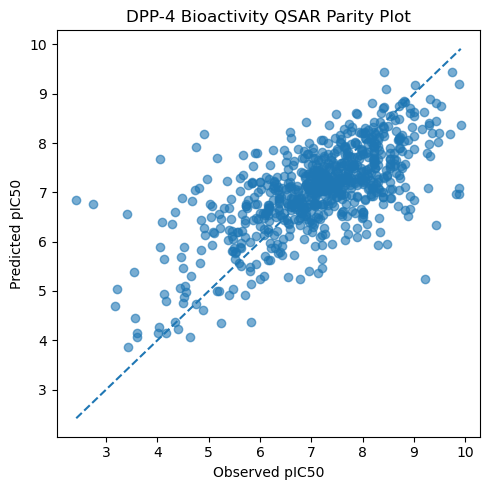

In [11]:
# Scientific interpretation + parity plot:
# Parity plot (Observed vs Predicted pIC50)

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.title("DPP-4 Bioactivity QSAR Parity Plot")
plt.tight_layout()
plt.show()


# scientific interpretation of the DPP-4 QSAR model (what drives activity)
# Why performance is lower than solubility (and that’s OK)
# Bioactivity (pIC50) is driven by:
# Specific binding interactions
# Shape complementarity
# Local functional groups
# These are harder to learn than bulk physicochemical properties like solubility
# So: R² ≈ 0.5–0.75 is good; RMSE ≈ 0.6–1.0 pIC50 is typical
# model mainly captures:
# Size (MolWt) → too large = steric penalty
# Lipophilicity (LogP) → affects binding and desolvation
# HBD/HBA → hydrogen bonds in the DPP-4 active site
# TPSA → balance between polarity and permeability

In [ ]:
# ECFP fingerprints for DPP-4 and compare vs descriptors
# 1. Create ECFP4 fingerprints for DPP-4 datase

from rdkit.Chem import rdMolDescriptors
import numpy as np
import pandas as pd

def morgan_fp(mol, radius=2, n_bits=2048):
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, radius, nBits=n_bits
    )
    return np.array(fp)

X_fp = np.vstack(df["mol"].apply(morgan_fp).values)
X_fp = pd.DataFrame(X_fp)

print("ECFP matrix shape:", X_fp.shape)
X_fp.iloc[:5, :10]

In [15]:
print(X_fp.shape)


(3728, 2048)


In [20]:
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd

# Create Morgan (ECFP4) generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def morgan_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

# Build fingerprint matrix
X_fp = pd.DataFrame(
    np.vstack(df["mol"].apply(morgan_fp).values)
)

print("ECFP matrix shape:", X_fp.shape)


ECFP matrix shape: (3728, 2048)


In [19]:
# ECFP fingerprints for DPP-4 and compare vs descriptors
# 2. Train ECFP QSAR and evaluate

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train_fp, X_test_fp, y_train, y_test = train_test_split(
    X_fp, y, test_size=0.2, random_state=42
)

model_fp = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model_fp.fit(X_train_fp, y_train)
y_pred_fp = model_fp.predict(X_test_fp)

r2_fp = r2_score(y_test, y_pred_fp)
rmse_fp = np.sqrt(mean_squared_error(y_test, y_pred_fp))

print("DPP-4 ECFP R2:", round(r2_fp, 3))
print("DPP-4 ECFP RMSE:", round(rmse_fp, 3))


DPP-4 ECFP R2: 0.636
DPP-4 ECFP RMSE: 0.743


In [21]:
# 
# Create a comparison table (descriptors vs ECFP)

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Descriptors (RF)",
        "ECFP4 (RF)"
    ],
    "R2": [
        r2,
        r2_fp
    ],
    "RMSE": [
        rmse,
        rmse_fp
    ]
})

comparison


,Model,R2,RMSE
0,Descriptors (RF),0.441875,0.919580
1,ECFP4 (RF),0.636050,0.742582


In [22]:
# Scaffold split (chem-aware validation)
# 1. Create Murcko scaffolds and scaffold split for DPP-4

from rdkit.Chem.Scaffolds import MurckoScaffold

# Murcko scaffold SMILES for each molecule
df["scaffold"] = df["mol"].apply(lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m))

# Sort scaffolds by frequency (largest first)
scaffold_counts = df["scaffold"].value_counts()
scaffolds_sorted = list(scaffold_counts.index)

# Fill train scaffolds until ~80% of data
train_scaffolds = set()
train_target = int(0.8 * len(df))
current = 0

for scaf in scaffolds_sorted:
    n = scaffold_counts[scaf]
    if current + n <= train_target:
        train_scaffolds.add(scaf)
        current += n

train_idx = df[df["scaffold"].isin(train_scaffolds)].index
test_idx = df[~df["scaffold"].isin(train_scaffolds)].index

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Unique scaffolds train:", df.loc[train_idx, "scaffold"].nunique())
print("Unique scaffolds test:", df.loc[test_idx, "scaffold"].nunique())


Train size: 2982
Test size: 746
Unique scaffolds train: 568
Unique scaffolds test: 746


In [24]:
# Scaffold split (chem-aware validation)
# 2 Evaluate BOTH models using scaffold split

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ---------- Descriptor model on scaffold split ----------
X_train_scaf = X.loc[train_idx]
X_test_scaf = X.loc[test_idx]
y_train_scaf = y.loc[train_idx]
y_test_scaf = y.loc[test_idx]

model.fit(X_train_scaf, y_train_scaf)
y_pred_scaf_desc = model.predict(X_test_scaf)

r2_scaf_desc = r2_score(y_test_scaf, y_pred_scaf_desc)
rmse_scaf_desc = np.sqrt(mean_squared_error(y_test_scaf, y_pred_scaf_desc))


# ---------- ECFP model on scaffold split ----------
X_train_fp_scaf = X_fp.loc[train_idx]
X_test_fp_scaf = X_fp.loc[test_idx]

model_fp.fit(X_train_fp_scaf, y_train_scaf)
y_pred_scaf_fp = model_fp.predict(X_test_fp_scaf)

r2_scaf_fp = r2_score(y_test_scaf, y_pred_scaf_fp)
rmse_scaf_fp = np.sqrt(mean_squared_error(y_test_scaf, y_pred_scaf_fp))


print("Scaffold split — Descriptors R2:", round(r2_scaf_desc, 3))
print("Scaffold split — Descriptors RMSE:", round(rmse_scaf_desc, 3))
print("Scaffold split — ECFP R2:", round(r2_scaf_fp, 3))
print("Scaffold split — ECFP RMSE:", round(rmse_scaf_fp, 3))


# What to expect (important)
# Scaffold R² lower than random split (this is good)
# Often: ECFP ≥ descriptors on scaffold split; But both drop (honest difficulty)

Scaffold split — Descriptors R2: 0.204
Scaffold split — Descriptors RMSE: 1.199
Scaffold split — ECFP R2: 0.43
Scaffold split — ECFP RMSE: 1.014


In [25]:
# Final scientific interpretation + saving results
# 1. Save models, metrics, and figures (DPP-4)

import os
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np

# Create folders
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# Save models
joblib.dump(model, "../models/dpp4_descriptor_rf.joblib")
joblib.dump(model_fp, "../models/dpp4_ecfp_rf.joblib")

# Save metrics
metrics = {
    "random_split": {
        "descriptors": {"R2": float(r2), "RMSE": float(rmse)},
        "ecfp": {"R2": float(r2_fp), "RMSE": float(rmse_fp)}
    },
    "scaffold_split": {
        "descriptors": {"R2": float(r2_scaf_desc), "RMSE": float(rmse_scaf_desc)},
        "ecfp": {"R2": float(r2_scaf_fp), "RMSE": float(rmse_scaf_fp)}
    }
}

with open("../reports/dpp4_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Models and metrics saved.")


Models and metrics saved.


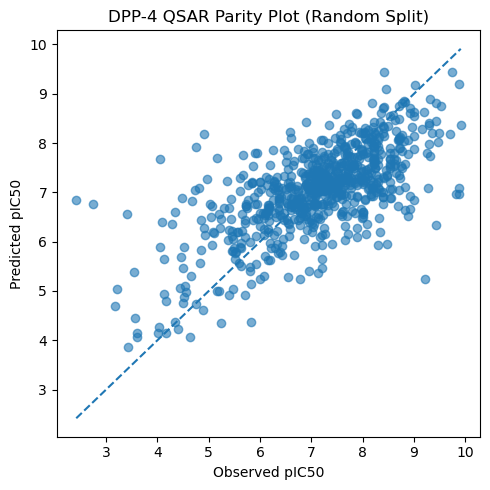

Saved: reports/figures/dpp4_parity_random.png


In [26]:
# Final scientific interpretation + saving results
# 2. Save models, metrics, and figures (DPP-4)

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.title("DPP-4 QSAR Parity Plot (Random Split)")
plt.tight_layout()
plt.savefig("../reports/figures/dpp4_parity_random.png", dpi=300)
plt.show()

print("Saved: reports/figures/dpp4_parity_random.png")
